# 01 — Hill Climbing y Random Restart

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

Al finalizar este notebook podrás:

- representar un problema de optimización mediante estados, vecinos y una función objetivo;
- implementar **Hill Climbing** para un problema discreto;
- identificar óptimos locales y mesetas;
- usar **Random Restart** para mejorar la exploración.

En los notebooks nos concentraremos en experimentar. La formalización y las propiedades de los algoritmos se presentan en las diapositivas.

## 1. Problema de ubicación de hospitales

Tenemos una cuadrícula con varias casas y queremos ubicar $k$ hospitales. El costo de una solución es la suma de la distancia de cada casa al hospital más cercano.

Usaremos distancia Manhattan:

$$
d((r_1,c_1),(r_2,c_2)) = |r_1-r_2|+|c_1-c_2|
$$

El problema es

$$
\min_{H} \sum_{c\in C}\min_{h\in H}d(c,h)
$$

- $C$: conjunto de casas.
- $H$: conjunto de hospitales.
- Un vecino se obtiene moviendo un hospital una celda arriba, abajo, izquierda o derecha.

![HillClimbing](https://drive.google.com/uc?export=view&id=1Vb7q8PCqTw-8WkalRWqtB86ovmLhrU1r)


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(min(manhattan(house, hospital) for hospital in hospitals)
               for house in houses)


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        hr, hc = zip(*houses)
        ax.scatter(hc, hr, marker='s', s=110, label='Casas')
    if hospitals:
        rr, cc = zip(*hospitals)
        ax.scatter(cc, rr, marker='P', s=180, label='Hospitales')

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f'Costo = {total_cost(houses, hospitals)}')
    plt.tight_layout()
    plt.show()

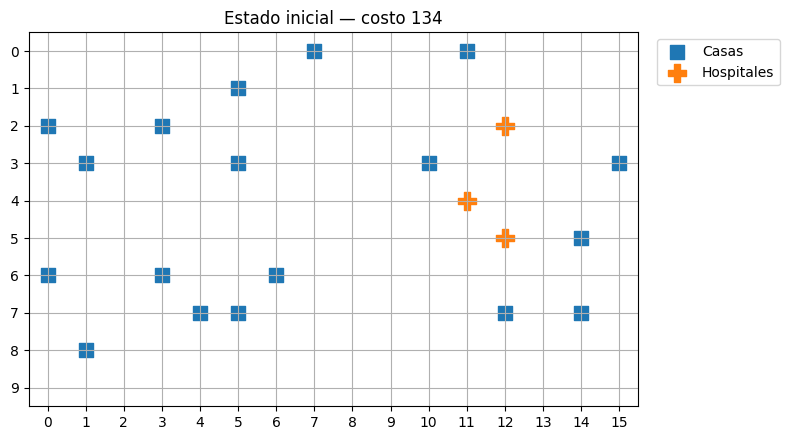

In [ ]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [(r, c) for r in range(HEIGHT) for c in range(WIDTH)]
houses = set(random.sample(all_cells, NUM_HOUSES))
available = list(set(all_cells) - houses)
initial_hospitals = set(random.sample(available, NUM_HOSPITALS))

plot_state(HEIGHT, WIDTH, houses, initial_hospitals,
           title=f'Estado inicial — costo {total_cost(houses, initial_hospitals)}')

## 2. Vecindario

Para generar estados vecinos moveremos **un hospital a la vez** hacia una celda adyacente disponible.

In [ ]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors

neighbors = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
print('Número de vecinos:', len(neighbors))
print('Costo actual:', total_cost(houses, initial_hospitals))
print('Mejor costo vecino:', min(total_cost(houses, n) for n in neighbors))

Número de vecinos: 12
Costo actual: 134
Mejor costo vecino: 125


## 3. Hill Climbing

En cada iteración:

1. generamos todos los vecinos;
2. calculamos sus costos;
3. nos movemos al vecino con menor costo;
4. detenemos el proceso cuando ningún vecino mejora la solución.

Costo inicial: 134
Costo final: 62
Iteraciones con mejora: 13


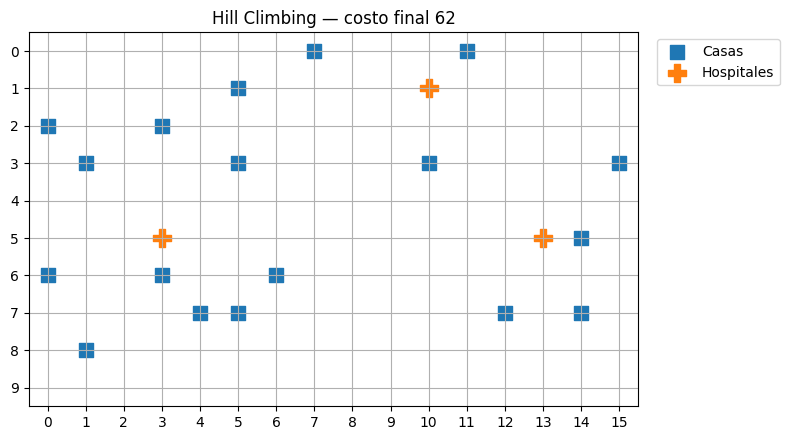

In [ ]:
def hill_climbing(height, width, houses, num_hospitals, initial_state=None,
                  max_iterations=200, rng=None):
    rng = rng or random.Random()
    available = list(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals))
    history = [total_cost(houses, current)]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(height, width, houses, current)
        if not neighbors:
            break

        costs = [total_cost(houses, n) for n in neighbors]
        best_cost = min(costs)
        current_cost = history[-1]

        if best_cost >= current_cost:
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost]
        current = set(rng.choice(best_neighbors))
        history.append(best_cost)
        states.append(set(current))

    return current, history, states

solution, history, states = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED)
)

print('Costo inicial:', history[0])
print('Costo final:', history[-1])
print('Iteraciones con mejora:', len(history) - 1)
plot_state(HEIGHT, WIDTH, houses, solution,
           title=f'Hill Climbing — costo final {history[-1]}')

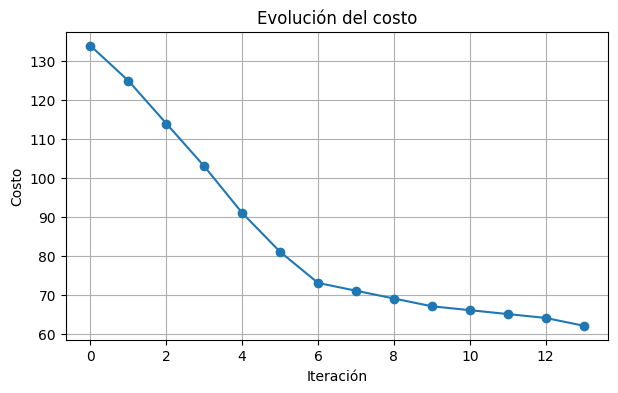

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(range(len(history)), history, marker='o')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.title('Evolución del costo')
plt.grid(True)
plt.show()

## 4. Random Restart

Una corrida de Hill Climbing puede terminar en un óptimo local. Random Restart ejecuta el algoritmo desde diferentes estados iniciales y conserva la mejor solución encontrada.

Mejor costo: 56
Reinicio ganador: 2


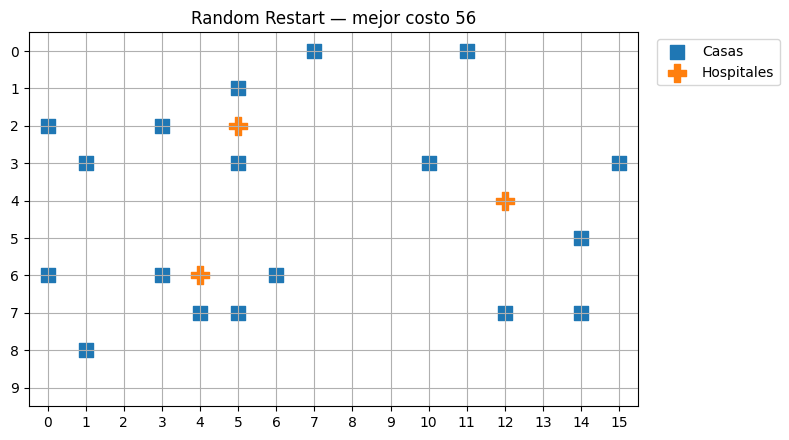

In [ ]:
def random_restart(height, width, houses, num_hospitals, restarts=30, seed=0):
    master_rng = random.Random(seed)
    runs = []
    best = None

    for restart in range(restarts):
        run_seed = master_rng.randrange(10**9)
        solution, history, _ = hill_climbing(
            height, width, houses, num_hospitals,
            rng=random.Random(run_seed)
        )
        record = {
            'restart': restart,
            'solution': solution,
            'initial_cost': history[0],
            'final_cost': history[-1],
            'iterations': len(history) - 1
        }
        runs.append(record)
        if best is None or record['final_cost'] < best['final_cost']:
            best = record

    return best, runs

best, runs = random_restart(HEIGHT, WIDTH, houses, NUM_HOSPITALS, restarts=40, seed=SEED)
print('Mejor costo:', best['final_cost'])
print('Reinicio ganador:', best['restart'])
plot_state(HEIGHT, WIDTH, houses, best['solution'],
           title=f'Random Restart — mejor costo {best["final_cost"]}')

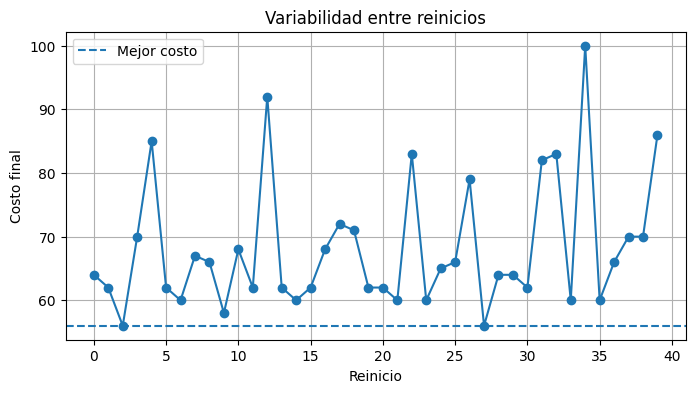

In [ ]:
final_costs = [run['final_cost'] for run in runs]
plt.figure(figsize=(8, 4))
plt.plot(final_costs, marker='o')
plt.axhline(min(final_costs), linestyle='--', label='Mejor costo')
plt.xlabel('Reinicio')
plt.ylabel('Costo final')
plt.title('Variabilidad entre reinicios')
plt.legend()
plt.grid(True)
plt.show()

## Actividades

### Actividad 1 — Distancia euclídea

Modifica la función de costo para usar

$$
d(a,b)=\sqrt{(a_r-b_r)^2+(a_c-b_c)^2}
$$

Compara la ubicación de los hospitales y el costo con la distancia Manhattan.

Manhattan: [(2, 5), (4, 12), (6, 4)] - costo: 56
Euclídea: [(2, 4), (5, 13), (7, 3)] - costo: 44.45


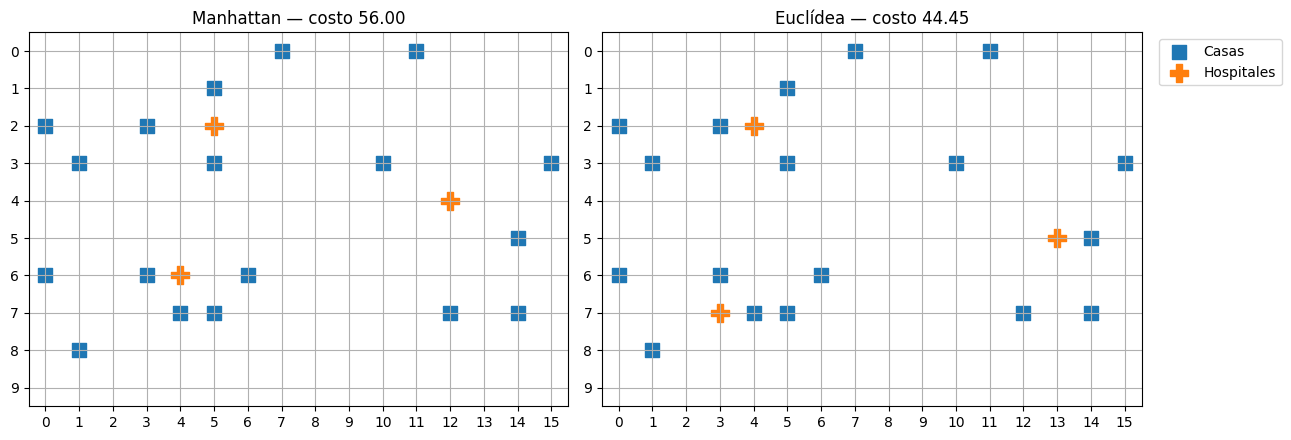

In [ ]:
# Actividad 1: distancia euclídea y funciones configurables.
def euclidean(a, b):
    return np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)


def total_cost_euclidean(houses, hospitals):
    return sum(min(euclidean(house, hospital) for hospital in hospitals)
               for house in houses)


def hill_climbing_custom(height, width, houses, num_hospitals, cost_fn,
                         neighbor_fn=neighbors_of_state, initial_state=None,
                         max_iterations=200, rng=None):
    rng = rng or random.Random()
    cells = [(r, c) for r in range(height) for c in range(width)]
    available = list(set(cells) - houses)
    current = (set(initial_state) if initial_state is not None
               else set(rng.sample(available, num_hospitals)))
    history = [cost_fn(houses, current)]
    evaluated = 0

    for _ in range(max_iterations):
        neighbors = neighbor_fn(height, width, houses, current)
        evaluated += len(neighbors)
        if not neighbors:
            break
        costs = [cost_fn(houses, state) for state in neighbors]
        best_cost = min(costs)
        if best_cost >= history[-1]:
            break
        candidates = [state for state, cost in zip(neighbors, costs)
                      if cost == best_cost]
        current = set(rng.choice(candidates))
        history.append(best_cost)

    return current, history, evaluated


def random_restart_custom(height, width, houses, num_hospitals, cost_fn,
                          neighbor_fn=neighbors_of_state, restarts=40, seed=0):
    master_rng = random.Random(seed)
    runs = []
    for restart in range(restarts):
        solution, history, evaluated = hill_climbing_custom(
            height, width, houses, num_hospitals, cost_fn, neighbor_fn,
            rng=random.Random(master_rng.randrange(10**9)))
        runs.append({'restart': restart, 'solution': solution,
                     'initial_cost': history[0], 'final_cost': history[-1],
                     'iterations': len(history) - 1, 'evaluated': evaluated})
    return min(runs, key=lambda run: run['final_cost']), runs


best_manhattan, _ = random_restart_custom(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS, total_cost, seed=SEED)
best_euclidean, _ = random_restart_custom(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS, total_cost_euclidean, seed=SEED)

print('Manhattan:', sorted(best_manhattan['solution']),
      '- costo:', round(best_manhattan['final_cost'], 2))
print('Euclídea:', sorted(best_euclidean['solution']),
      '- costo:', round(best_euclidean['final_cost'], 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, record, name, cost_fn in [
    (axes[0], best_manhattan, 'Manhattan', total_cost),
    (axes[1], best_euclidean, 'Euclídea', total_cost_euclidean)]:
    hr, hc = zip(*houses)
    rr, cc = zip(*record['solution'])
    ax.scatter(hc, hr, marker='s', s=90, label='Casas')
    ax.scatter(cc, rr, marker='P', s=160, label='Hospitales')
    ax.set(xlim=(-0.5, WIDTH - 0.5), ylim=(HEIGHT - 0.5, -0.5),
           title=f'{name} — costo {cost_fn(houses, record["solution"]):.2f}')
    ax.set_xticks(range(WIDTH)); ax.set_yticks(range(HEIGHT)); ax.grid(True)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()


### Actividad 2 — Número de hospitales

Ejecuta Random Restart para $k\in\{1,2,3,4,5\}$. Registra el mejor costo y discute si agregar hospitales produce siempre la misma reducción.

k | mejor costo | reducción frente al k anterior
1 |      114.00 | -
2 |       76.00 | 38
3 |       56.00 | 20
4 |       46.00 | 10
5 |       38.00 | 8


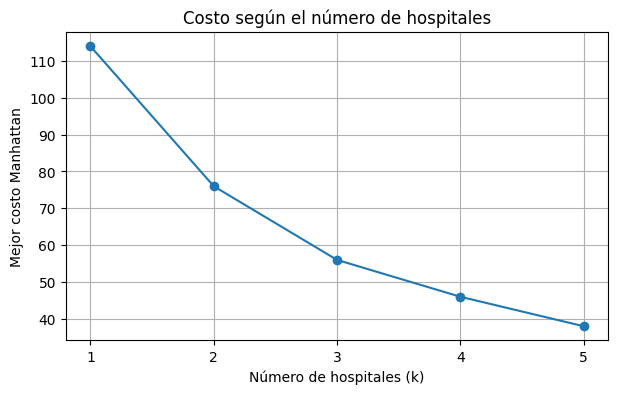

Conclusión: agregar hospitales reduce o mantiene el costo, pero la reducción no es igual en cada paso.


In [ ]:
results = []

for k in range(1, 6):
    best_k, _ = random_restart_custom(
        HEIGHT,
        WIDTH,
        houses,
        k,
        total_cost,
        restarts=40,
        seed=SEED
    )

    results.append((k, best_k["final_cost"]))

print("k | mejor costo | reducción frente al k anterior")

previous = None

for k, cost in results:
    reduction = "-" if previous is None else previous - cost
    print(f"{k} | {cost:11.2f} | {reduction}")
    previous = cost

ks, costs = zip(*results)

plt.figure(figsize=(7, 4))
plt.plot(ks, costs, marker="o")
plt.xticks(ks)
plt.xlabel("Número de hospitales (k)")
plt.ylabel("Mejor costo Manhattan")
plt.title("Costo según el número de hospitales")
plt.grid(True)
plt.show()

print(
    "Conclusión: agregar hospitales reduce o mantiene el costo, "
    "pero la reducción no es igual en cada paso."
)


### Actividad 3 — Diseño del vecindario

Actualmente un hospital solo se mueve una celda. Crea un vecindario que permita movimientos de hasta dos celdas. ¿Mejora el resultado? ¿Cuánto aumenta el número de vecinos evaluados?



In [ ]:
# Actividad 3: movimientos cardinales de una o dos celdas.
def neighbors_up_to_two(height, width, houses, hospitals):
    neighbors = []
    moves = [(-d, 0) for d in (1, 2)] + [(d, 0) for d in (1, 2)]
    moves += [(0, -d) for d in (1, 2)] + [(0, d) for d in (1, 2)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue
            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)
    return neighbors


# Misma semilla y mismos 40 reinicios para una comparación justa.
best_one, runs_one = random_restart_custom(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS, total_cost,
    neighbors_of_state, restarts=40, seed=SEED)
best_two, runs_two = random_restart_custom(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS, total_cost,
    neighbors_up_to_two, restarts=40, seed=SEED)

avg_one = np.mean([run['evaluated'] for run in runs_one])
avg_two = np.mean([run['evaluated'] for run in runs_two])
initial_one = len(neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals))
initial_two = len(neighbors_up_to_two(HEIGHT, WIDTH, houses, initial_hospitals))

print('Vecindario | mejor costo | vecinos iniciales | evaluaciones promedio/corrida')
print(f'1 celda    | {best_one["final_cost"]:11.2f} | {initial_one:17d} | {avg_one:.2f}')
print(f'Hasta 2    | {best_two["final_cost"]:11.2f} | {initial_two:17d} | {avg_two:.2f}')
print(f'Aumento de vecinos iniciales: {initial_two - initial_one} '
      f'({(initial_two / initial_one - 1) * 100:.1f}%)')
print(f'Aumento de evaluaciones promedio: {avg_two - avg_one:.2f} '
      f'({(avg_two / avg_one - 1) * 100:.1f}%)')

if best_two['final_cost'] < best_one['final_cost']:
    print('Conclusión: mover hasta dos celdas sí mejoró el mejor costo.')
elif best_two['final_cost'] == best_one['final_cost']:
    print('Conclusión: ambos vecindarios alcanzaron el mismo mejor costo.')
else:
    print('Conclusión: el vecindario mayor no mejoró el mejor costo.')
print('Un vecindario mayor ofrece más opciones, pero exige evaluar más estados.')


Vecindario | mejor costo | vecinos iniciales | evaluaciones promedio/corrida
1 celda    |       56.00 |                12 | 78.15
Hasta 2    |       56.00 |                22 | 145.05
Aumento de vecinos iniciales: 10 (83.3%)
Aumento de evaluaciones promedio: 66.90 (85.6%)
Conclusión: ambos vecindarios alcanzaron el mismo mejor costo.
Un vecindario mayor ofrece más opciones, pero exige evaluar más estados.


## Preguntas de cierre

1. ¿Por qué Hill Climbing no necesita construir todo el espacio de búsqueda?

Porque solo analiza los estados vecinos de la solución actual. En cada iteración elige el vecino que mejora más el costo, sin generar ni almacenar todas las posibles ubicaciones de los hospitales. Esto reduce el uso de memoria y el tiempo de búsqueda.

2. ¿El resultado depende del estado inicial?

Sí. Hill Climbing puede seguir caminos diferentes dependiendo de la ubicación inicial de los hospitales. Algunos estados iniciales pueden conducir a mejores soluciones, mientras que otros pueden terminar en óptimos locales.

3. ¿Random Restart garantiza encontrar el óptimo global?

No lo garantiza. Random Restart aumenta la probabilidad de encontrar una buena solución porque ejecuta Hill Climbing desde varios estados iniciales, pero todavía podría no visitar la solución óptima global. Entre más reinicios se realicen, mayor será la posibilidad de encontrarla, aunque también aumentará el tiempo de ejecución.

4. ¿Qué información se pierde al conservar únicamente el mejor vecino?

Se descartan los demás vecinos y los posibles caminos que se podrían explorar desde ellos. Alguno de esos vecinos podría tener inicialmente un costo menos favorable, pero conducir después a una solución global mejor. Por esta razón, Hill Climbing puede quedar atrapado en óptimos locales o mesetas.